# Credit Scoring Model - 03: Univariate Analysis

**Objective:** Analyze the distribution of each individual feature.

---

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from eda_utils import load_data, plot_distribution

# Enable inline plotting for Jupyter
%matplotlib inline

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = load_data('../data/cs-training-cleaned.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('✓ Using cleaned data from notebook 02 (missing values imputed with mean method)')

Dataset loaded: 150,000 rows × 11 columns
✓ Using cleaned data from notebook 02 (missing values imputed with mean method)


## 1. Age Distribution

✓ Figure saved: ../outputs/03_age_distribution.png


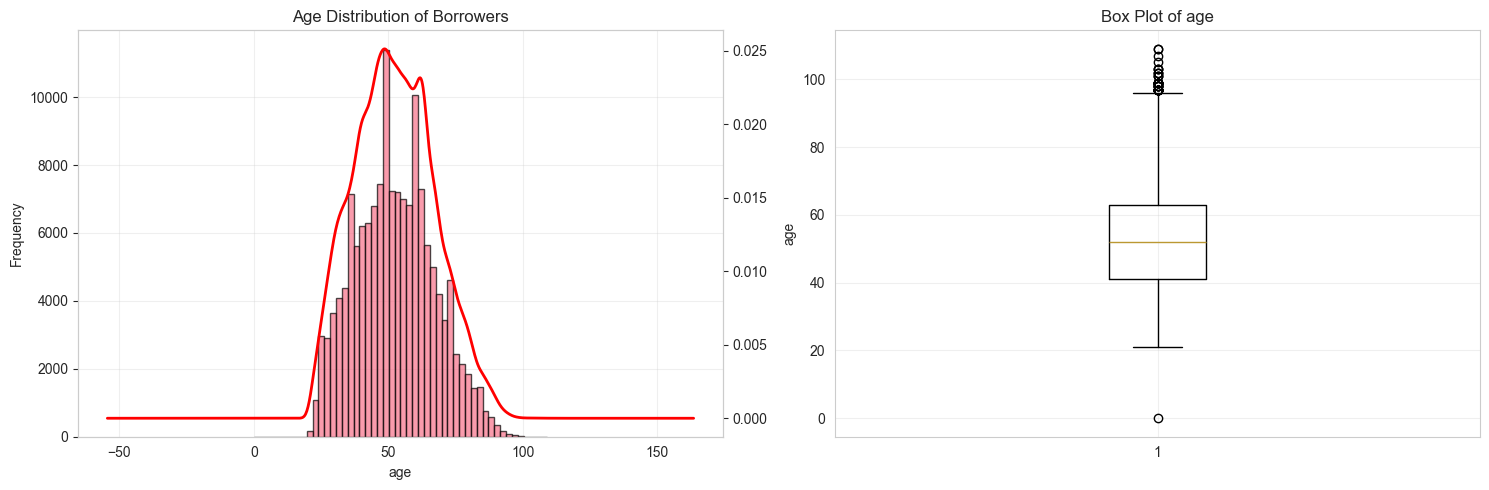

Age Statistics:
  Mean:   52.3 years
  Median: 52.0 years
  Range:  0 - 109 years


In [2]:
fig = plot_distribution(df, 'age', 'Age Distribution of Borrowers')
fig.savefig(f'{OUTPUT_DIR}/03_age_distribution.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/03_age_distribution.png')
plt.show()

print(f'Age Statistics:')
print(f'  Mean:   {df["age"].mean():.1f} years')
print(f'  Median: {df["age"].median():.1f} years')
print(f'  Range:  {df["age"].min():.0f} - {df["age"].max():.0f} years')

## 2. Credit Utilization Distribution

✓ Figure saved: ../outputs/03_credit_utilization_distribution.png


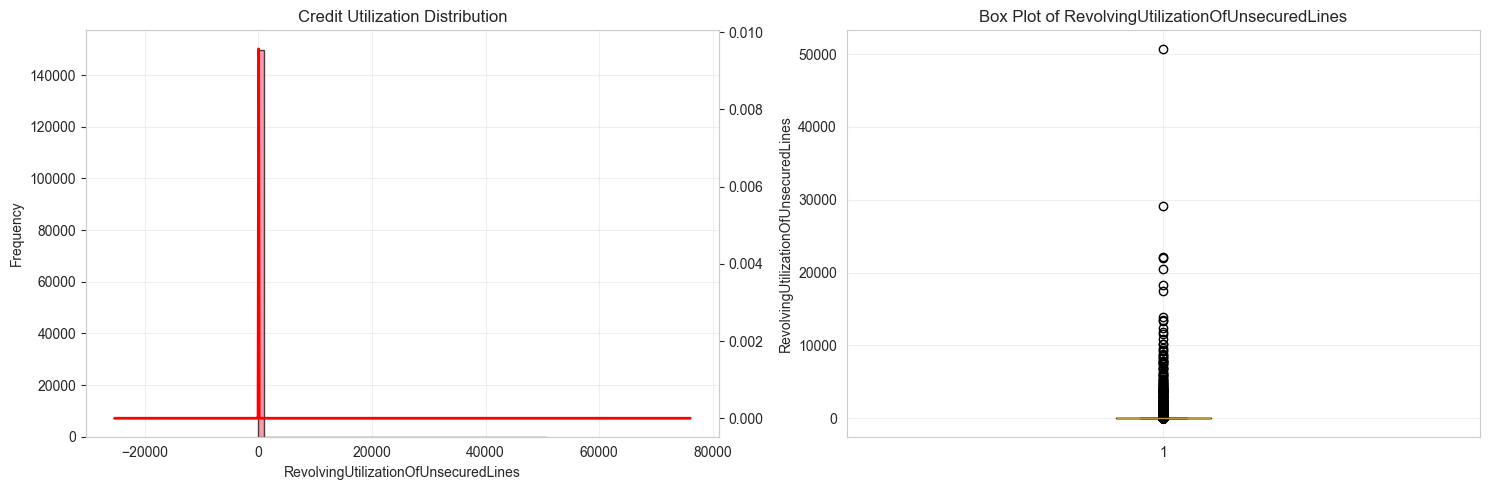

Borrowers with over-utilization (>100%): 3,321 (2.21%)
⚠️  Over-utilization indicates borrowers exceeding their credit limits - high risk indicator


In [3]:
fig = plot_distribution(df, 'RevolvingUtilizationOfUnsecuredLines', 'Credit Utilization Distribution')
fig.savefig(f'{OUTPUT_DIR}/03_credit_utilization_distribution.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/03_credit_utilization_distribution.png')
plt.show()

over_util = (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()
over_util_pct = (over_util / len(df)) * 100
print(f'Borrowers with over-utilization (>100%): {over_util:,} ({over_util_pct:.2f}%)')
print('⚠️  Over-utilization indicates borrowers exceeding their credit limits - high risk indicator')

## 3. Monthly Income Distribution

✓ Figure saved: ../outputs/03_monthly_income_distribution.png


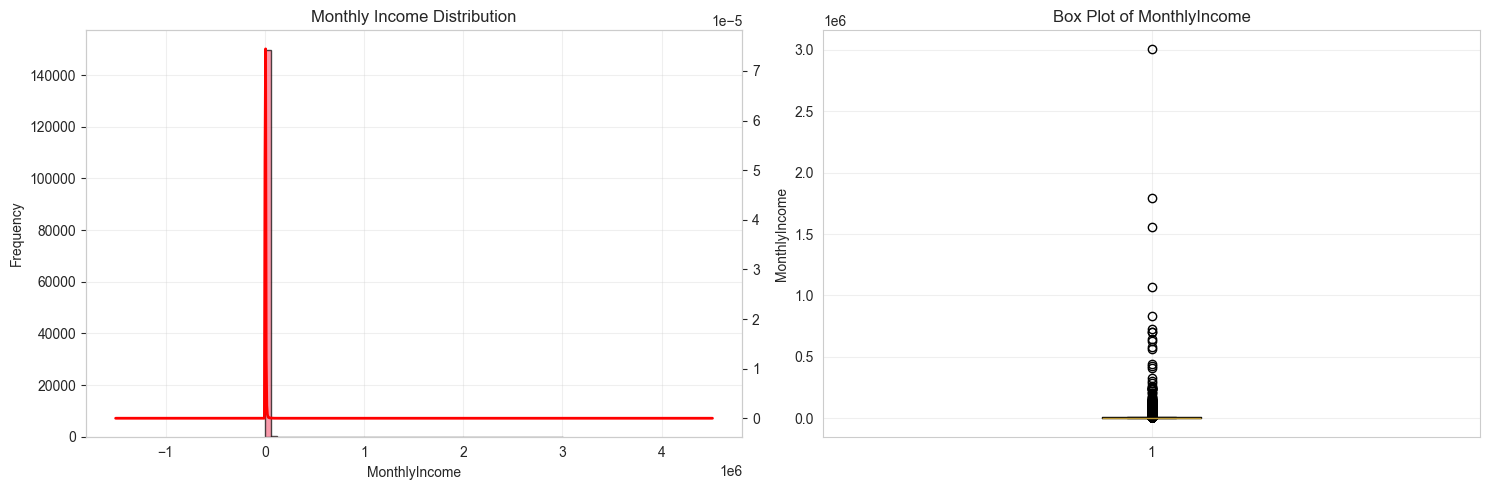

Monthly Income Statistics:
  Mean:    $6,418.45
  Median:  $5,400.00
  Missing: 0 (0.00%)


In [4]:
fig = plot_distribution(df, 'MonthlyIncome', 'Monthly Income Distribution')
fig.savefig(f'{OUTPUT_DIR}/03_monthly_income_distribution.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/03_monthly_income_distribution.png')
plt.show()

print(f'Monthly Income Statistics:')
print(f'  Mean:    ${df["MonthlyIncome"].mean():,.2f}')
print(f'  Median:  ${df["MonthlyIncome"].median():,.2f}')
print(f'  Missing: {df["MonthlyIncome"].isnull().sum():,} ({df["MonthlyIncome"].isnull().sum()/len(df)*100:.2f}%)')

## 4. Debt Ratio Distribution

✓ Figure saved: ../outputs/03_debt_ratio_distribution.png


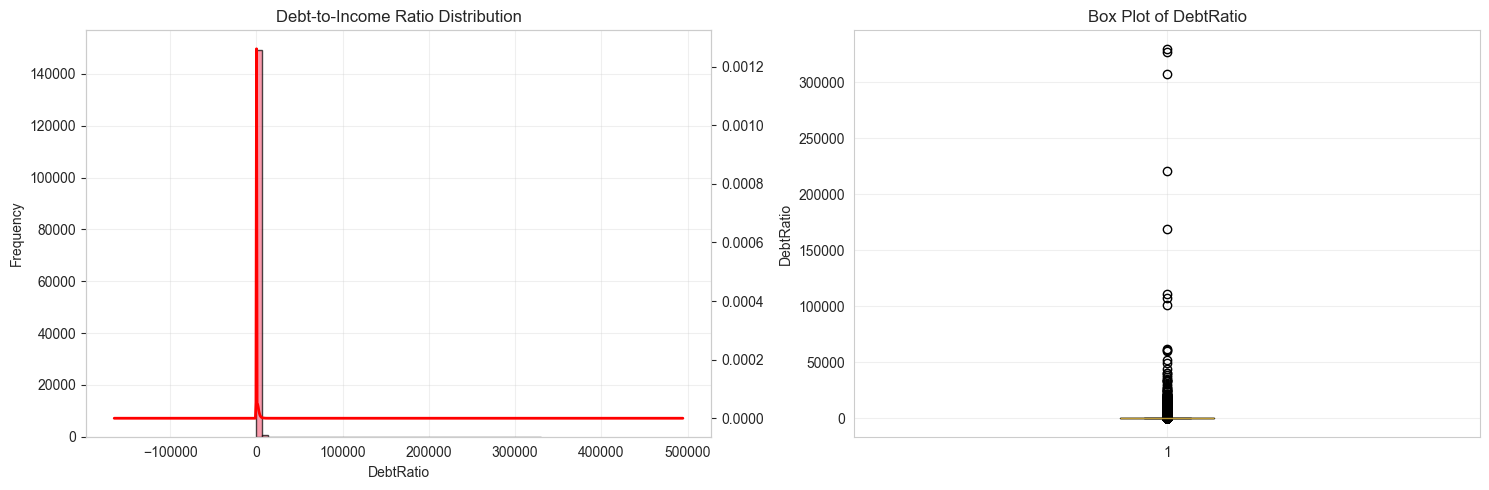

Debt Ratio Categories:
  Low    (<36%):  73,861 (49.24%)
  Medium (36-50%): 19,841 (13.23%)
  High   (>50%):  56,298 (37.53%)


In [5]:
fig = plot_distribution(df, 'DebtRatio', 'Debt-to-Income Ratio Distribution')
fig.savefig(f'{OUTPUT_DIR}/03_debt_ratio_distribution.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/03_debt_ratio_distribution.png')
plt.show()

low_debt   = (df['DebtRatio'] < 0.36).sum()
medium_debt = ((df['DebtRatio'] >= 0.36) & (df['DebtRatio'] < 0.5)).sum()
high_debt  = (df['DebtRatio'] >= 0.5).sum()
print(f'Debt Ratio Categories:')
print(f'  Low    (<36%):  {low_debt:,} ({low_debt/len(df)*100:.2f}%)')
print(f'  Medium (36-50%): {medium_debt:,} ({medium_debt/len(df)*100:.2f}%)')
print(f'  High   (>50%):  {high_debt:,} ({high_debt/len(df)*100:.2f}%)')

## 5. Payment Delinquency Analysis

✓ Figure saved: ../outputs/03_delinquency_analysis.png


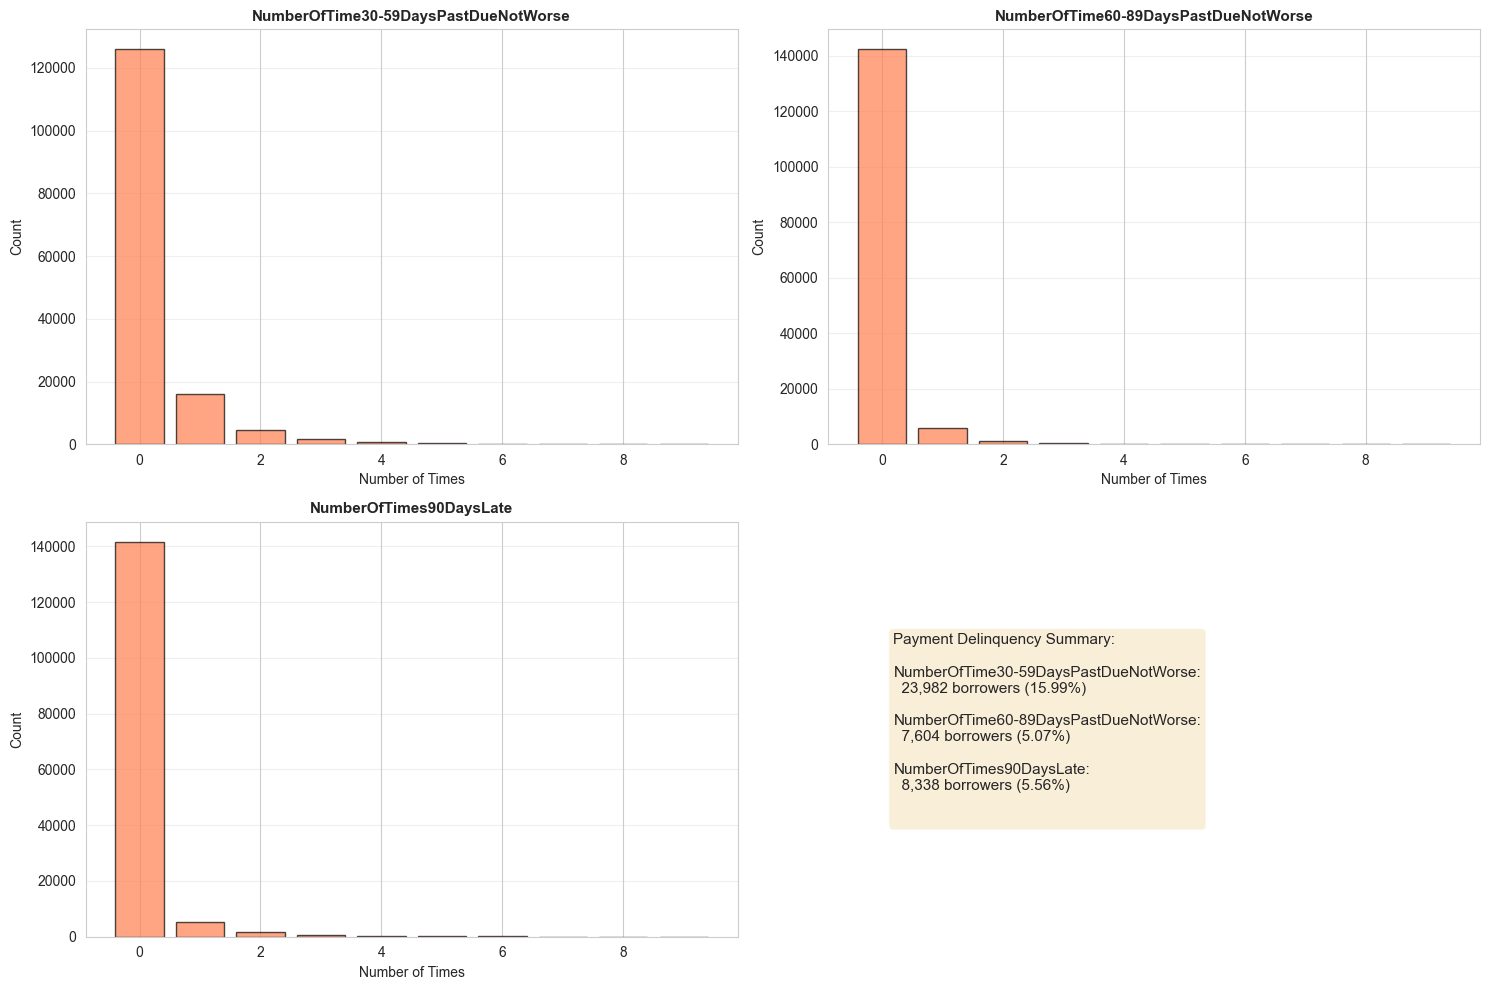


✓ Notebook 03 complete. Figures saved to outputs/


In [6]:
delinquency_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for idx, col in enumerate(delinquency_cols):
    row = idx // 2
    col_idx = idx % 2
    value_counts = df[col].value_counts().sort_index().head(10)
    axes[row, col_idx].bar(value_counts.index, value_counts.values,
                           color='coral', edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[row, col_idx].set_xlabel('Number of Times')
    axes[row, col_idx].set_ylabel('Count')
    axes[row, col_idx].grid(axis='y', alpha=0.3)

# Summary in 4th subplot
axes[1, 1].axis('off')
summary_text = 'Payment Delinquency Summary:\n\n'
for col in delinquency_cols:
    has_delinq = (df[col] > 0).sum()
    pct = (has_delinq / len(df)) * 100
    summary_text += f'{col}:\n  {has_delinq:,} borrowers ({pct:.2f}%)\n\n'
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/03_delinquency_analysis.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/03_delinquency_analysis.png')
plt.show()

print('\n✓ Notebook 03 complete. Figures saved to outputs/')